In [6]:
# %% Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix)
from xgboost import XGBClassifier

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

In [9]:
# %% Cell 2: Load Data + Basic Info
df = pd.read_csv(r"C:\Users\admin\Downloads\Gas_Sensors_Measurements (2).csv")

print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nDtypes:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (6400, 9)

Head:
    Serial Number  MQ2  MQ3  MQ5  MQ6  MQ7  MQ8  MQ135    Gas
0              0  555  515  377  338  666  451    416  NoGas
1              1  555  516  377  339  666  451    416  NoGas
2              2  556  517  376  337  666  451    416  NoGas
3              3  556  516  376  336  665  451    416  NoGas
4              4  556  516  376  337  665  451    416  NoGas

Dtypes:
 Serial Number     int64
MQ2               int64
MQ3               int64
MQ5               int64
MQ6               int64
MQ7               int64
MQ8               int64
MQ135             int64
Gas              object
dtype: object

Missing Values:
 Serial Number    0
MQ2              0
MQ3              0
MQ5              0
MQ6              0
MQ7              0
MQ8              0
MQ135            0
Gas              0
dtype: int64


In [10]:
# %% Cell 3: Clean Data — Nulls + Outliers (IQR)
df = df.drop(columns=["Serial Number"], errors="ignore")
df["Gas"] = df["Gas"].astype(str).str.strip()
df = df.dropna()

feature_cols = ["MQ2", "MQ3", "MQ5", "MQ6", "MQ7", "MQ8", "MQ135"]

print("Rows before outlier removal:", df.shape[0])

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Rows after outlier removal:", df.shape[0])

df = df.drop_duplicates()
print("Rows after removing duplicates:", df.shape[0])

Rows before outlier removal: 6400
Rows after outlier removal: 6341
Rows after removing duplicates: 6113


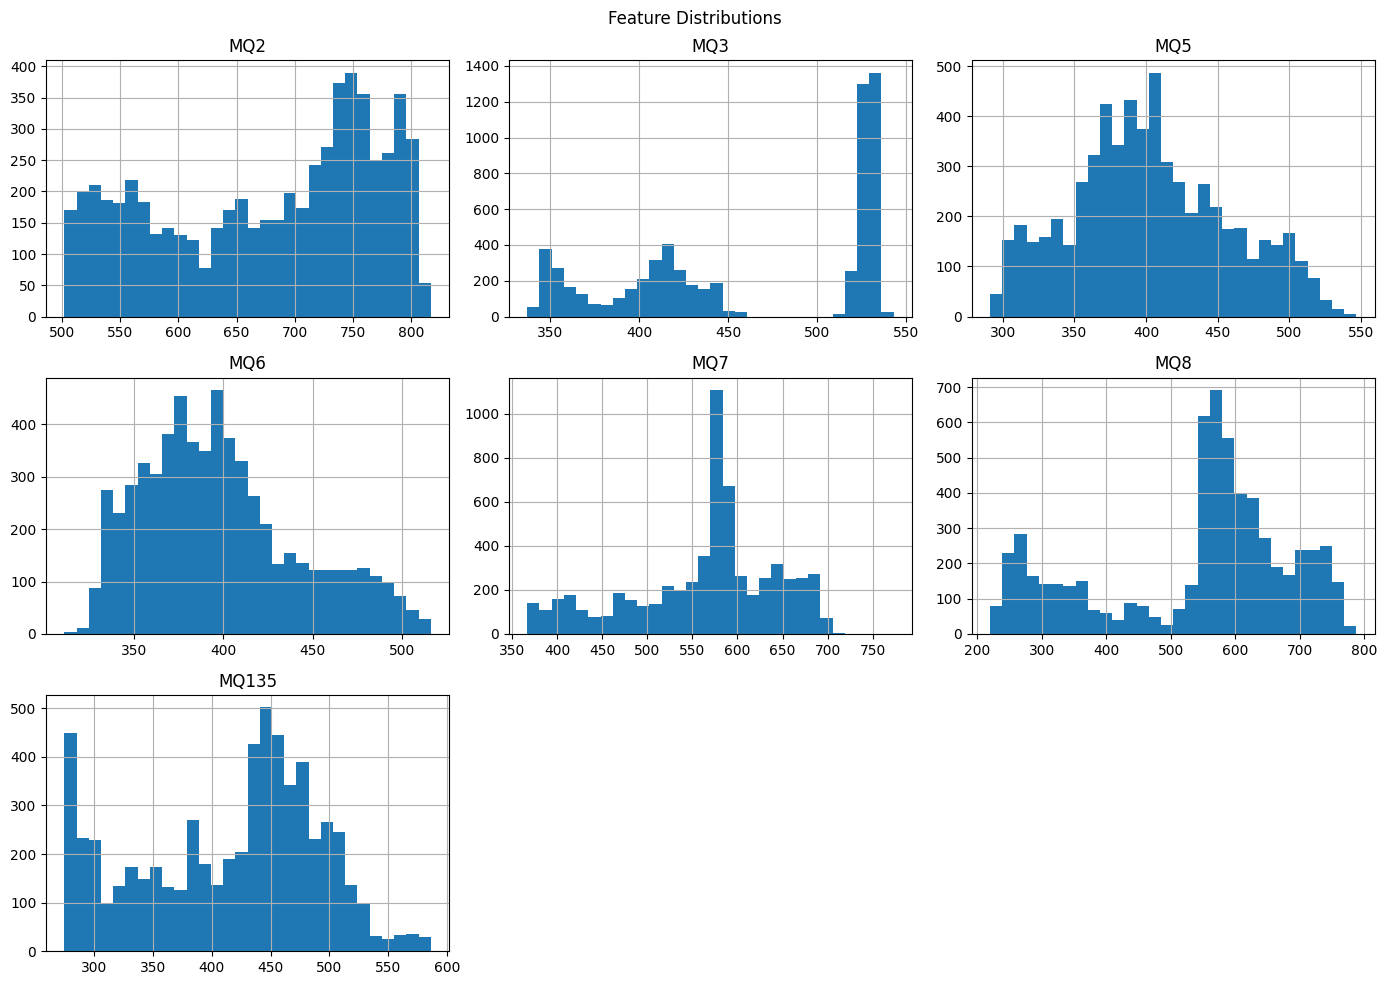

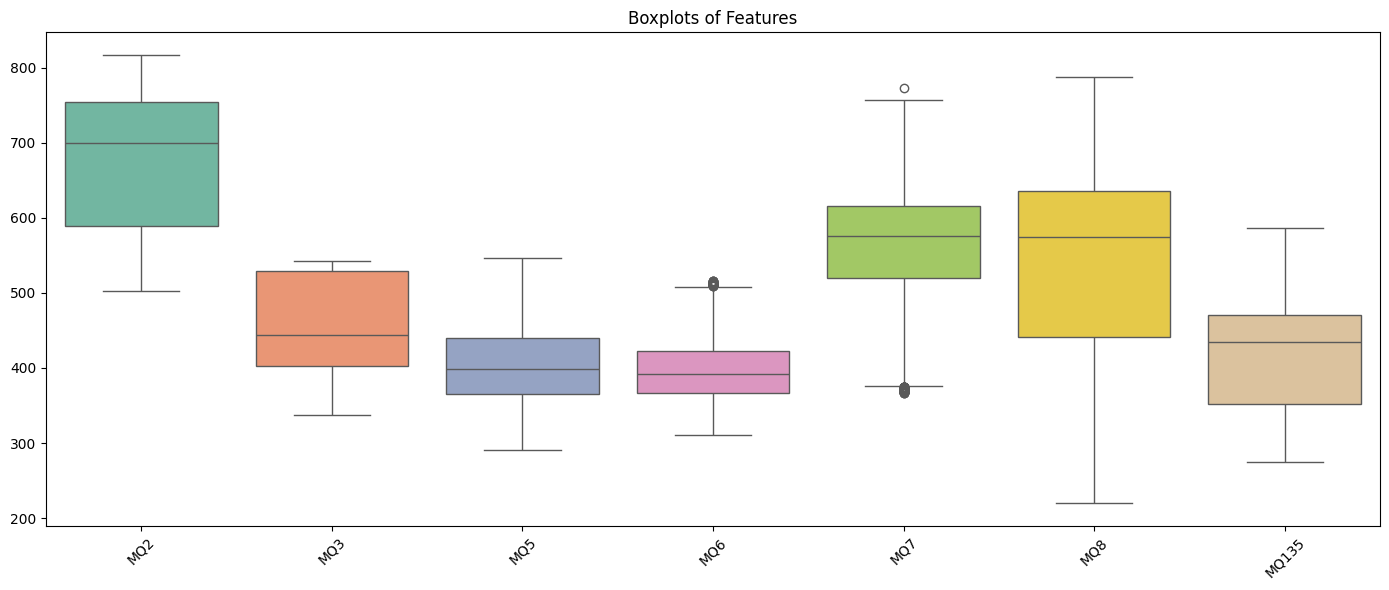

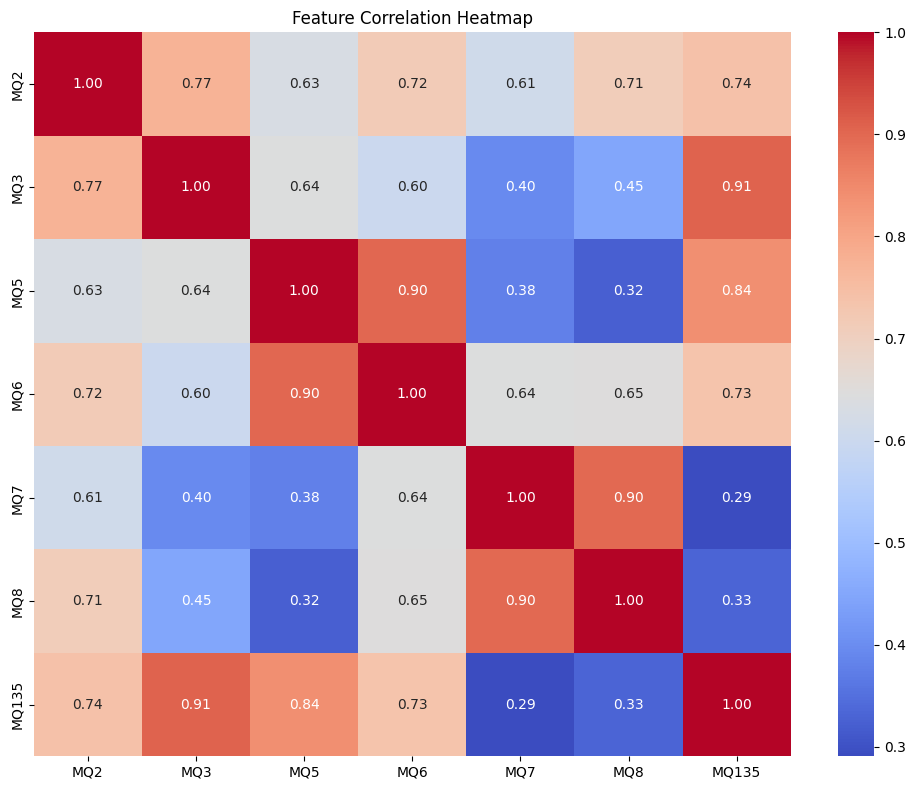

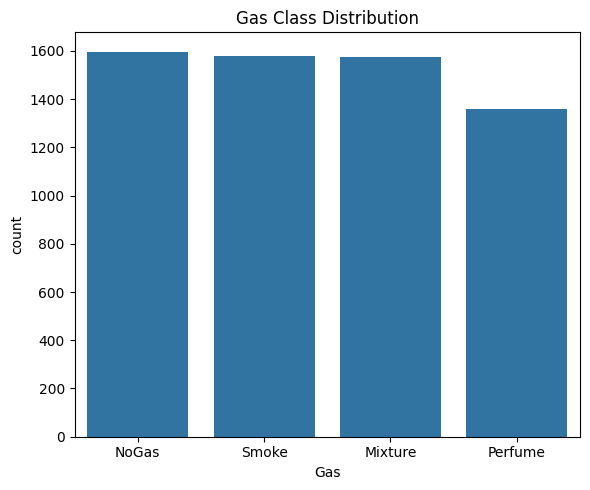

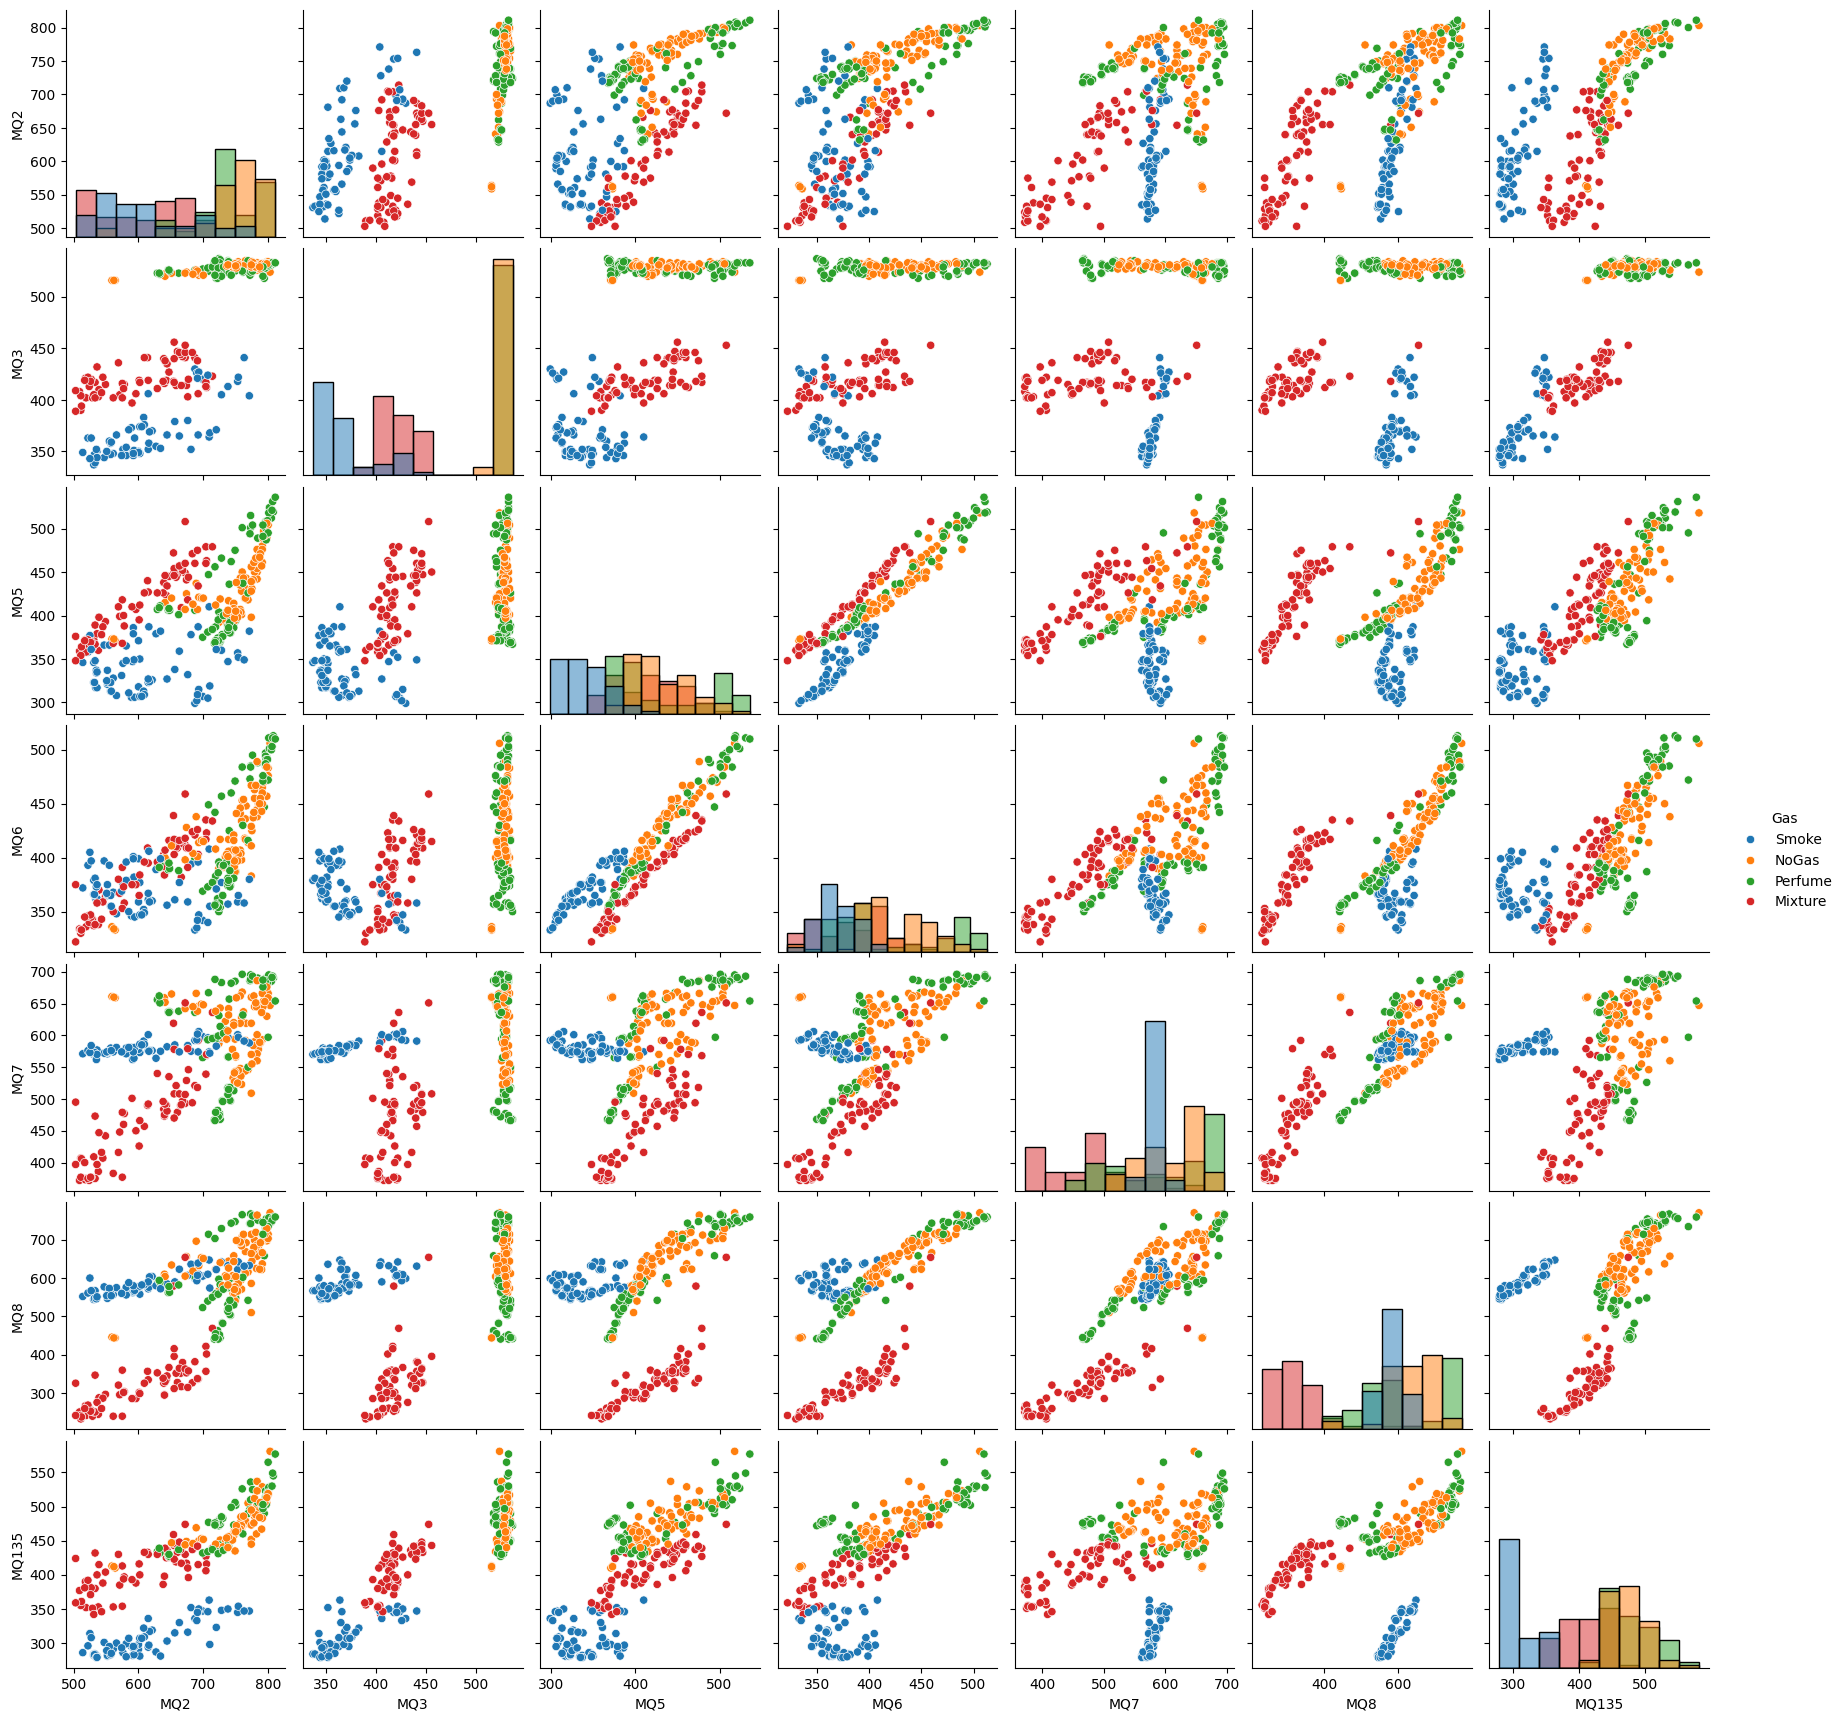

In [11]:
# %% Cell 4: Visualize Everything
df[feature_cols].hist(figsize=(14, 10), bins=30)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[feature_cols], palette="Set2")
plt.xticks(rotation=45)
plt.title("Boxplots of Features")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.countplot(x="Gas", data=df, order=df["Gas"].value_counts().index)
plt.title("Gas Class Distribution")
plt.tight_layout()
plt.show()

sample_df = df.sample(min(300, len(df)), random_state=RANDOM_STATE)
sns.pairplot(sample_df, vars=feature_cols, hue="Gas", diag_kind="hist")
plt.show()

In [12]:
# %% Cell 5: Train-Test Split + Feature Scaling
le = LabelEncoder()
df["Gas_Label"] = le.fit_transform(df["Gas"])
print("Class Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df[feature_cols]
y = df["Gas_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Class Mapping: {'Mixture': np.int64(0), 'NoGas': np.int64(1), 'Perfume': np.int64(2), 'Smoke': np.int64(3)}
Train shape: (4890, 7)
Test shape: (1223, 7)


In [13]:
# %% Cell 6: Train and Compare Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, eval_metric='mlogloss', random_state=RANDOM_STATE)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, average='weighted')
    recall = recall_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')

    results[name] = {
        "model": model, "train_acc": train_acc, "test_acc": test_acc,
        "precision": precision, "recall": recall, "f1": f1
    }

comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Train Accuracy": [results[m]["train_acc"] for m in results],
    "Test Accuracy": [results[m]["test_acc"] for m in results],
    "Precision": [results[m]["precision"] for m in results],
    "Recall": [results[m]["recall"] for m in results],
    "F1 Score": [results[m]["f1"] for m in results]
}).sort_values("Test Accuracy", ascending=False)

print(comparison_df)

                 Model  Train Accuracy  Test Accuracy  Precision    Recall  \
5              XGBoost        1.000000       0.977105   0.977128  0.977105   
2        Random Forest        1.000000       0.973835   0.973835  0.973835   
3    Gradient Boosting        0.993661       0.970564   0.970571  0.970564   
1        Decision Tree        1.000000       0.959117   0.959111  0.959117   
4                  SVM        0.945399       0.946852   0.946979  0.946852   
0  Logistic Regression        0.826789       0.817661   0.817644  0.817661   

   F1 Score  
5  0.977112  
2  0.973835  
3  0.970547  
1  0.959111  
4  0.946885  
0  0.812866  


Best Model: XGBoost
Train Accuracy: 1.0000
Test Accuracy: 0.9771
Gap: 0.0229

Classification Report (Test):
              precision    recall  f1-score   support

     Mixture       1.00      1.00      1.00       315
       NoGas       0.96      0.95      0.96       320
     Perfume       0.95      0.95      0.95       272
       Smoke       1.00      1.00      1.00       316

    accuracy                           0.98      1223
   macro avg       0.98      0.98      0.98      1223
weighted avg       0.98      0.98      0.98      1223



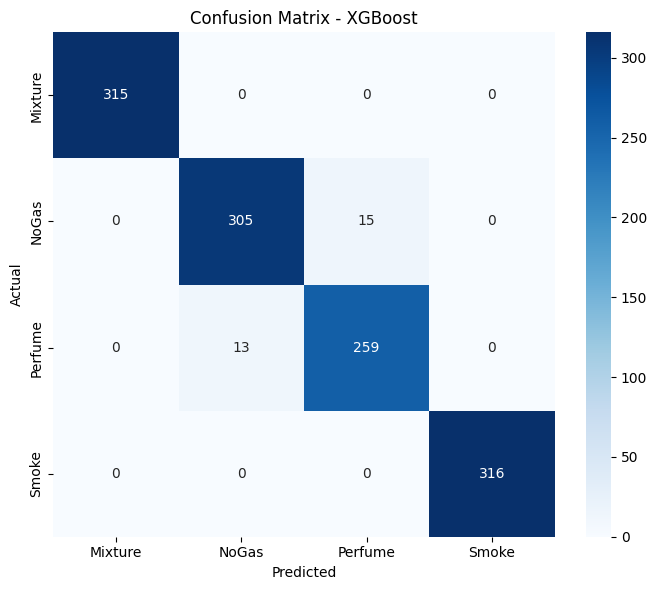


Verdict: Good Fit


In [14]:
# %% Cell 7: Best Model Evaluation — Overfitting/Underfitting Check
best_name = comparison_df.iloc[0]["Model"]
best_model = results[best_name]["model"]

y_train_pred = best_model.predict(X_train_scaled)
y_test_pred = best_model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Best Model: {best_name}")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Gap: {abs(train_acc - test_acc):.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

gap = abs(train_acc - test_acc)
if train_acc > 0.95 and gap > 0.08:
    verdict = "Overfitting"
elif train_acc < 0.75 and test_acc < 0.75:
    verdict = "Underfitting"
else:
    verdict = "Good Fit"
print(f"\nVerdict: {verdict}")

In [15]:
# %% Cell 8: Test Best Model on 5 Random Test Rows
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_test.index, 5, replace=False)

sample_X = X_test.loc[sample_idx]
sample_X_scaled = scaler.transform(sample_X)
sample_y_actual = y_test.loc[sample_idx]
sample_y_pred = best_model.predict(sample_X_scaled)

result_df = pd.DataFrame({
    "Actual": le.inverse_transform(sample_y_actual),
    "Predicted": le.inverse_transform(sample_y_pred),
    "Correct": le.inverse_transform(sample_y_actual) == le.inverse_transform(sample_y_pred)
})

print(result_df)

    Actual Predicted  Correct
0  Mixture   Mixture     True
1  Mixture   Mixture     True
2    Smoke     Smoke     True
3    NoGas     NoGas     True
4  Mixture   Mixture     True


In [16]:
# %% Cell 9: Manual Input Prediction
print("Enter sensor readings:")
mq2 = float(input("MQ2: "))
mq3 = float(input("MQ3: "))
mq5 = float(input("MQ5: "))
mq6 = float(input("MQ6: "))
mq7 = float(input("MQ7: "))
mq8 = float(input("MQ8: "))
mq135 = float(input("MQ135: "))

manual_input = pd.DataFrame([[mq2, mq3, mq5, mq6, mq7, mq8, mq135]], columns=feature_cols)
manual_input_scaled = scaler.transform(manual_input)

prediction = best_model.predict(manual_input_scaled)
predicted_class = le.inverse_transform(prediction)[0]

print(f"\nPredicted Gas Type: {predicted_class}")

Enter sensor readings:


MQ2:  555
MQ3:  515
MQ5:  377
MQ6:  338
MQ7:  666
MQ8:  451
MQ135:  416



Predicted Gas Type: NoGas


In [17]:
# %% Cell 10: Save Model and Scaler
joblib.dump(best_model, "best_gas_type_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model, scaler, and label encoder saved successfully.")

Model, scaler, and label encoder saved successfully.


     Class  Precision    Recall  F1-Score  Support
0  Mixture   1.000000  1.000000  1.000000      315
1    NoGas   0.959119  0.953125  0.956113      320
2  Perfume   0.945255  0.952206  0.948718      272
3    Smoke   1.000000  1.000000  1.000000      316


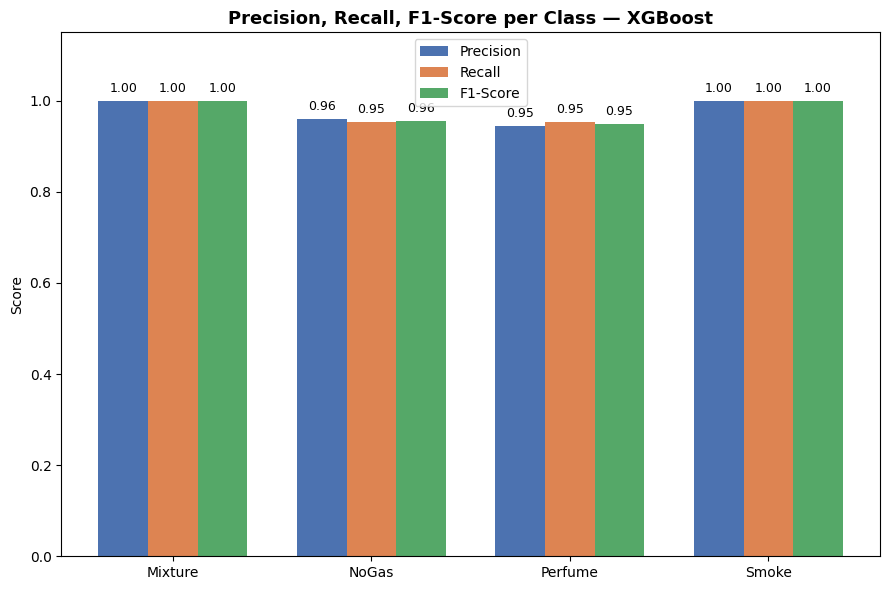

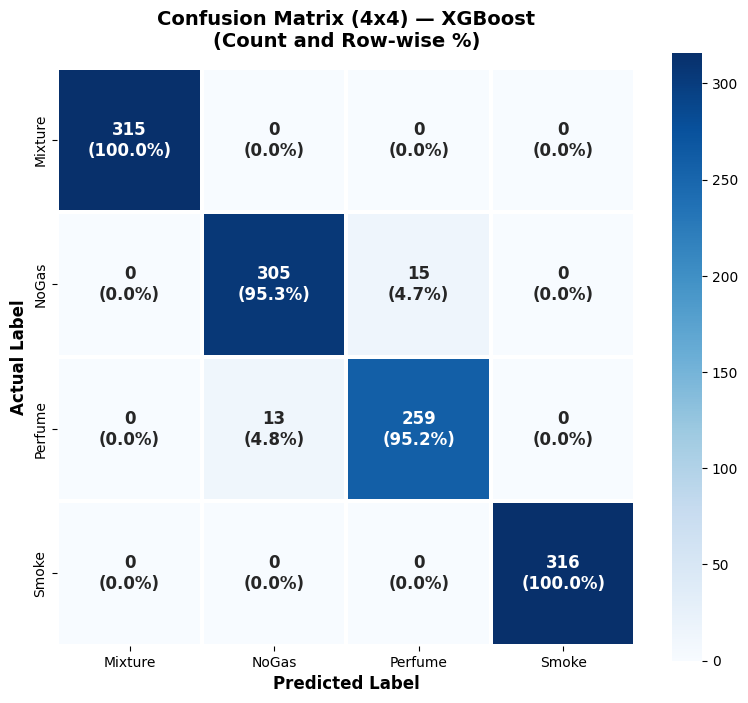

Row-wise totals (should match actual class counts in y_test):
Mixture: 315 (actual in y_test: 315)
NoGas: 320 (actual in y_test: 320)
Perfume: 272 (actual in y_test: 272)
Smoke: 316 (actual in y_test: 316)

Overall Accuracy : 0.9771
Overall Precision: 0.9771
Overall Recall   : 0.9771
Overall F1-Score : 0.9771


In [20]:
# %% Cell 7B: Precision, Recall, F1 (Per-Class Bar Chart) + 4x4 Confusion Matrix
# ============================================
from sklearn.metrics import precision_recall_fscore_support

y_test_pred = best_model.predict(X_test_scaled)

# Per-class Precision, Recall, F1
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_test_pred, labels=range(len(le.classes_))
)

metrics_df = pd.DataFrame({
    "Class": le.classes_,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support
})

print(metrics_df)

# ---- Plot 1: Grouped Bar Chart ----
x = np.arange(len(le.classes_))
width = 0.25

plt.figure(figsize=(9, 6))
plt.bar(x - width, metrics_df["Precision"], width, label='Precision', color='#4C72B0')
plt.bar(x, metrics_df["Recall"], width, label='Recall', color='#DD8452')
plt.bar(x + width, metrics_df["F1-Score"], width, label='F1-Score', color='#55A868')

plt.xticks(x, le.classes_)
plt.ylim(0, 1.15)
plt.ylabel("Score")
plt.title(f"Precision, Recall, F1-Score per Class — {best_name}", fontsize=13, fontweight='bold')
plt.legend()

for i in range(len(x)):
    plt.text(x[i]-width, metrics_df["Precision"][i]+0.02, f"{metrics_df['Precision'][i]:.2f}", ha='center', fontsize=9)
    plt.text(x[i], metrics_df["Recall"][i]+0.02, f"{metrics_df['Recall'][i]:.2f}", ha='center', fontsize=9)
    plt.text(x[i]+width, metrics_df["F1-Score"][i]+0.02, f"{metrics_df['F1-Score'][i]:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ---- Plot 2: 4x4 Confusion Matrix (Count + Percentage) ----
cm = confusion_matrix(y_test, y_test_pred, labels=range(len(le.classes_)))
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

n_rows, n_cols = cm.shape
cell_text = [["" for _ in range(n_cols)] for _ in range(n_rows)]
for i in range(n_rows):
    for j in range(n_cols):
        cell_text[i][j] = f"{cm[i][j]}\n({cm_pct[i][j]:.1f}%)"

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=cell_text, fmt='', cmap='Blues', cbar=True,
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=1.5, linecolor='white',
            annot_kws={"size": 12, "weight": "bold"}, ax=ax, square=True)

ax.set_title(f"Confusion Matrix (4x4) — {best_name}\n(Count and Row-wise %)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Predicted Label", fontsize=12, fontweight='bold')
ax.set_ylabel("Actual Label", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ---- Sanity Check ----
print("Row-wise totals (should match actual class counts in y_test):")
for i, cls in enumerate(le.classes_):
    print(f"{cls}: {cm[i].sum()} (actual in y_test: {(y_test == i).sum()})")

# ---- Overall Weighted Metrics ----
overall_precision = precision_score(y_test, y_test_pred, average='weighted')
overall_recall = recall_score(y_test, y_test_pred, average='weighted')
overall_f1 = f1_score(y_test, y_test_pred, average='weighted')
overall_acc = accuracy_score(y_test, y_test_pred)

print(f"\nOverall Accuracy : {overall_acc:.4f}")
print(f"Overall Precision: {overall_precision:.4f}")
print(f"Overall Recall   : {overall_recall:.4f}")
print(f"Overall F1-Score : {overall_f1:.4f}")

In [21]:
# %% Cell 6: Train and Compare Models (Individual Results)
# ============================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, eval_metric='mlogloss', random_state=RANDOM_STATE)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, average='weighted')
    recall = recall_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')

    results[name] = {
        "model": model, "train_acc": train_acc, "test_acc": test_acc,
        "precision": precision, "recall": recall, "f1": f1,
        "y_test_pred": y_test_pred
    }

    # ---- Individual model result print ----
    print("=" * 55)
    print(f"MODEL: {name}")
    print("=" * 55)
    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Test Accuracy  : {test_acc:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print()

MODEL: Logistic Regression
Train Accuracy : 0.8268
Test Accuracy  : 0.8177
Precision      : 0.8176
Recall         : 0.8177
F1 Score       : 0.8129

MODEL: Decision Tree
Train Accuracy : 1.0000
Test Accuracy  : 0.9591
Precision      : 0.9591
Recall         : 0.9591
F1 Score       : 0.9591

MODEL: Random Forest
Train Accuracy : 1.0000
Test Accuracy  : 0.9738
Precision      : 0.9738
Recall         : 0.9738
F1 Score       : 0.9738

MODEL: Gradient Boosting
Train Accuracy : 0.9937
Test Accuracy  : 0.9706
Precision      : 0.9706
Recall         : 0.9706
F1 Score       : 0.9705

MODEL: SVM
Train Accuracy : 0.9454
Test Accuracy  : 0.9469
Precision      : 0.9470
Recall         : 0.9469
F1 Score       : 0.9469

MODEL: XGBoost
Train Accuracy : 1.0000
Test Accuracy  : 0.9771
Precision      : 0.9771
Recall         : 0.9771
F1 Score       : 0.9771



                 Model  Train Accuracy  Test Accuracy  Precision    Recall  \
0              XGBoost        1.000000       0.977105   0.977128  0.977105   
1        Random Forest        1.000000       0.973835   0.973835  0.973835   
2    Gradient Boosting        0.993661       0.970564   0.970571  0.970564   
3        Decision Tree        1.000000       0.959117   0.959111  0.959117   
4                  SVM        0.945399       0.946852   0.946979  0.946852   
5  Logistic Regression        0.826789       0.817661   0.817644  0.817661   

   F1 Score  
0  0.977112  
1  0.973835  
2  0.970547  
3  0.959111  
4  0.946885  
5  0.812866  


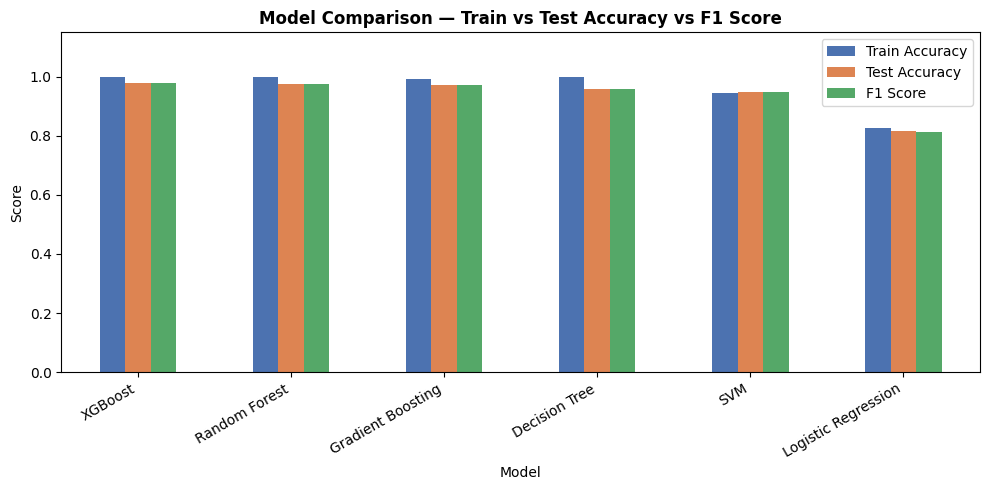

In [22]:
# %% Cell 6B: Comparison Table (All Models Together)
# ============================================
comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Train Accuracy": [results[m]["train_acc"] for m in results],
    "Test Accuracy": [results[m]["test_acc"] for m in results],
    "Precision": [results[m]["precision"] for m in results],
    "Recall": [results[m]["recall"] for m in results],
    "F1 Score": [results[m]["f1"] for m in results]
}).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

print(comparison_df)

# Bar chart comparison
comparison_df.set_index("Model")[["Train Accuracy", "Test Accuracy", "F1 Score"]].plot(
    kind="bar", figsize=(10, 5), color=["#4C72B0", "#DD8452", "#55A868"]
)
plt.title("Model Comparison — Train vs Test Accuracy vs F1 Score", fontweight='bold')
plt.ylabel("Score")
plt.ylim(0, 1.15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

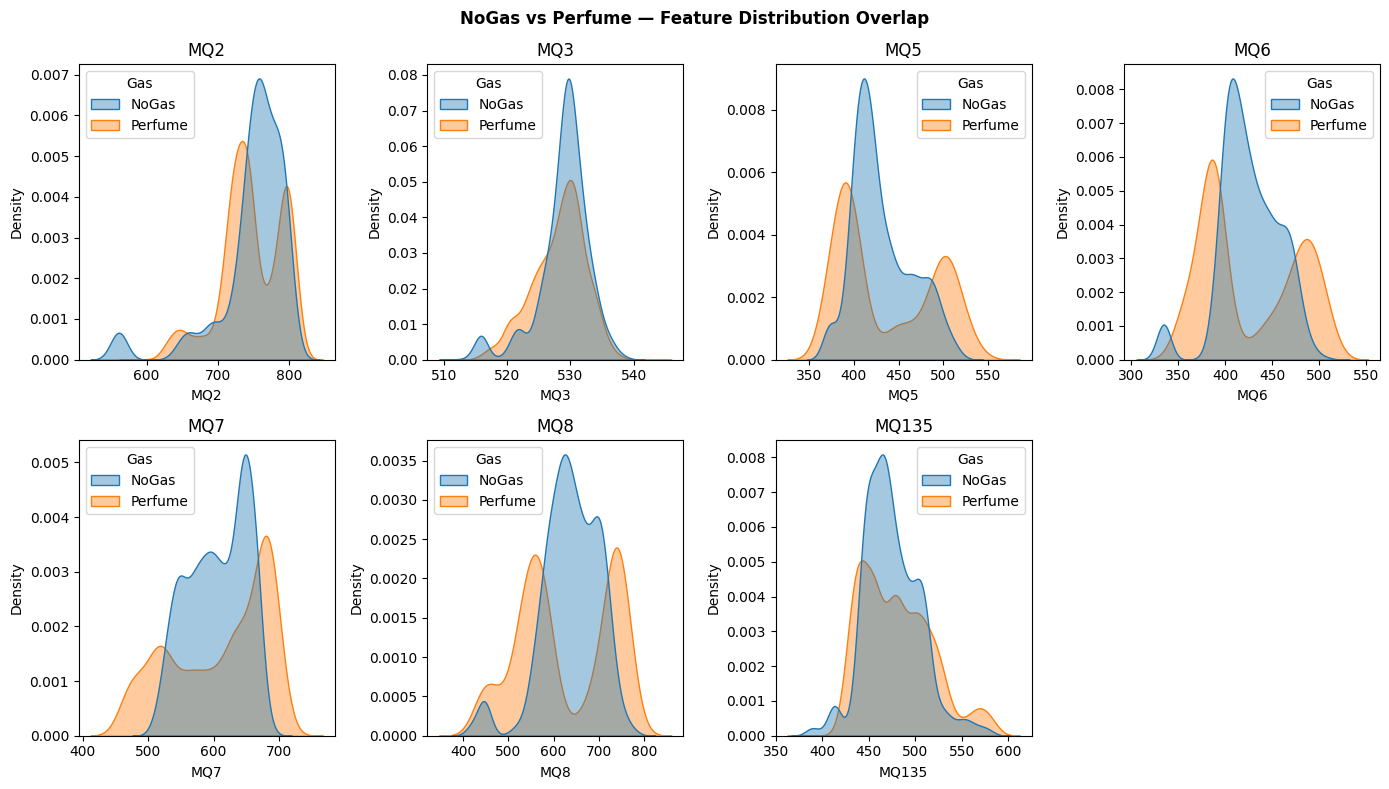

In [31]:
# ============================================
# Step 1: NoGas vs Perfume — Feature Analysis (kaunse sensors overlap kar rahe hain)
# ============================================
confused_mask = df["Gas"].isin(["NoGas", "Perfume"])
df_confused = df[confused_mask]

plt.figure(figsize=(14, 8))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(2, 4, i)
    sns.kdeplot(data=df_confused, x=col, hue="Gas", fill=True, alpha=0.4)
    plt.title(col)
plt.suptitle("NoGas vs Perfume — Feature Distribution Overlap", fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# ============================================
# Step 2: Feature Engineering — Interaction Features Add Karo
# ============================================
df["MQ_ratio_1"] = df["MQ3"] / (df["MQ135"] + 1)
df["MQ_ratio_2"] = df["MQ2"] / (df["MQ8"] + 1)
df["MQ_sum"] = df[feature_cols].sum(axis=1)
df["MQ_std"] = df[feature_cols].std(axis=1)

feature_cols_v2 = feature_cols + ["MQ_ratio_1", "MQ_ratio_2", "MQ_sum", "MQ_std"]

X_v2 = df[feature_cols_v2]
y_v2 = df["Gas_Label"]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=RANDOM_STATE, stratify=y_v2
)

scaler_v2 = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled = scaler_v2.transform(X_test_v2)

In [33]:
# ============================================
# Step 3: XGBoost with Engineered Features — Retrain
# ============================================
xgb_v2 = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                        eval_metric='mlogloss', random_state=RANDOM_STATE)
xgb_v2.fit(X_train_v2_scaled, y_train_v2)

y_pred_v2 = xgb_v2.predict(X_test_v2_scaled)
acc_v2 = accuracy_score(y_test_v2, y_pred_v2)

print(f"New Test Accuracy (with engineered features): {acc_v2:.4f}")
print(f"Old Test Accuracy (baseline): {results['XGBoost']['test_acc']:.4f}")

print("\nClassification Report (v2):")
print(classification_report(y_test_v2, y_pred_v2, target_names=le.classes_))

New Test Accuracy (with engineered features): 0.9796
Old Test Accuracy (baseline): 0.9771

Classification Report (v2):
              precision    recall  f1-score   support

     Mixture       1.00      1.00      1.00       315
       NoGas       0.97      0.96      0.96       320
     Perfume       0.95      0.96      0.96       272
       Smoke       1.00      1.00      1.00       316

    accuracy                           0.98      1223
   macro avg       0.98      0.98      0.98      1223
weighted avg       0.98      0.98      0.98      1223



In [34]:
# ============================================
# Step 4: Hyperparameter Tuning — Better XGBoost
# ============================================
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'min_child_weight': [1, 3, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE),
    param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1
)
grid.fit(X_train_v2_scaled, y_train_v2)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

best_xgb_tuned = grid.best_estimator_
y_pred_tuned = best_xgb_tuned.predict(X_test_v2_scaled)
print(f"\nTuned Test Accuracy: {accuracy_score(y_test_v2, y_pred_tuned):.4f}")
print(classification_report(y_test_v2, y_pred_tuned, target_names=le.classes_))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Params: {'learning_rate': 0.05, 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 500}
Best CV Accuracy: 0.9760736196319018

Tuned Test Accuracy: 0.9779
              precision    recall  f1-score   support

     Mixture       1.00      1.00      1.00       315
       NoGas       0.96      0.96      0.96       320
     Perfume       0.95      0.95      0.95       272
       Smoke       1.00      1.00      1.00       316

    accuracy                           0.98      1223
   macro avg       0.98      0.98      0.98      1223
weighted avg       0.98      0.98      0.98      1223



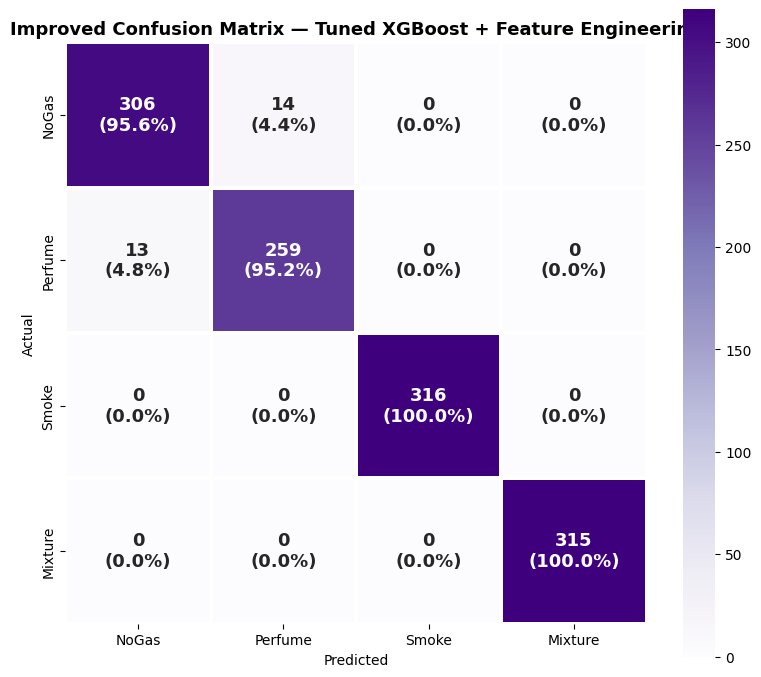

In [35]:
 # ============================================
# Step 5: New Confusion Matrix (After Improvement)
# ============================================
custom_order = ["NoGas", "Perfume", "Smoke", "Mixture"]
custom_indices = [list(le.classes_).index(cls) for cls in custom_order]

cm_new = confusion_matrix(y_test_v2, y_pred_tuned, labels=custom_indices)
cm_new_pct = cm_new.astype('float') / cm_new.sum(axis=1, keepdims=True) * 100

cell_text = [[f"{cm_new[i][j]}\n({cm_new_pct[i][j]:.1f}%)" for j in range(4)] for i in range(4)]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_new, annot=cell_text, fmt='', cmap='Purples', cbar=True,
            xticklabels=custom_order, yticklabels=custom_order,
            linewidths=1.5, linecolor='white', annot_kws={"size": 13, "weight": "bold"},
            ax=ax, square=True)
ax.set_title("Improved Confusion Matrix — Tuned XGBoost + Feature Engineering",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()